## This notebook make a plot showing different windows. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # --- Input Model Parameters ---
# n = 2.0
# N = 768
# dnuc = 40e-3             # MHz
# r = 9209.714526830916    # Mpc
# rp = 16.98990953034521   # Mpc/MHz
# dL = dnuc * rp
# L  = N * dL
# Nrea = 100

# # Try loading nua, else create dummy frequency array
# try:
#     nua = np.load('nua.npy') / 1e6
#     dnu = nua
# except FileNotFoundError:
#     print("Warning: 'nua.npy' not found. Using linear range.")
#     dnu = np.arange(N) * dnuc + 138.0 

# # --- Configuration ---
# path = "results"
# flag_mode = "PERIODIC"  # Updated to RANDOM
# NN_hann = 50 
# show_inset = False 

# # INDICES for the two realizations
# idx1 = 45
# idx2 = 90 

# # --- Helper to load data ---
# def get_data(inp_sig, scf_method, idx):
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# def get_data21(inp_sig, scf_method, idx):
#     # Loads NOFLAG data for the "Truth"
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig
    
# # --- Plotting Logic for Single Column ---
# def plot_realization(ax_top, ax_bot, idx, show_ylabel=True, show_legend=False):
#     # Load Data
#     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx) 
#     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx) 
    
#     # Load True 21cm (Filtered Residuals from NOFLAG run)
#     _, true_21cm, _ = get_data21("21cm", "GP", idx=idx) 
#     _, true_21cm_hann, _ = get_data21("21cm", "Hann", idx=idx) 

#     if res_hann is None or res_gp is None or true_21cm is None:
#         print(f"Error: Missing files for idx {idx}.")
#         return

#     # Data Prep
#     x_full = dnu
#     flag_mask = (res_gp != 0.0)
    
#     tota_fg_flagged = tota_fg_gp.copy()
#     tota_fg_flagged[~flag_mask] = np.nan 
#     true_21cm[~flag_mask] = np.nan 
    
#     # Fits
#     fit_gp = tota_fg_gp - res_gp
#     fit_gp[~flag_mask] = np.nan
    
#     x_hann = x_full[NN_hann : -NN_hann]
#     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
#     fit_hann = tota_hann_cut - res_hann
#     mask_hann = flag_mask[NN_hann : -NN_hann]
#     fit_hann[~mask_hann] = np.nan
#     true_21cm_hann[~mask_hann] = np.nan 
    
#     # Residuals
#     res_gp_masked = res_gp.copy()
#     res_gp_masked[~flag_mask] = np.nan
    
#     res_hann_masked = res_hann.copy()
#     res_hann_masked[res_hann_masked == 0] = np.nan
    
#     # --- GLOBAL FONT SIZES ---
#     FS_LABEL = 18 
#     FS_TICK  = 15 
#     FS_LEG   = 15 

#     ax_top.tick_params(axis='both', which='major', labelsize=FS_TICK)
#     ax_bot.tick_params(axis='both', which='major', labelsize=FS_TICK)

#     # --- Top Panel: Input + Fits ---
#     # Data (Black Solid)
#     ax_top.plot(x_full, tota_fg_flagged/1e6, color='k', linewidth=3, 
#                 label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
    
#     # Hann Fit (Blue Dashed)
#     ax_top.plot(x_hann, fit_hann/1e6, color='tab:blue', linestyle=':',  linewidth=1.5,
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
    
#     # GP Fit (Orange Dash-Dot)
#     ax_top.plot(x_full, fit_gp/1e6, color='tab:orange', linestyle='-', linewidth=1.5, 
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_top.set_ylabel(r"$T \ 10^6 \ \mathrm{mK}$", fontsize=FS_LABEL)
    
#     if show_legend:
#         ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
#     # --- Optional Inset ---
#     if show_inset:
#         center_idx = N // 2
#         zoom_width = 64
#         zoom_slice = slice(center_idx - zoom_width, center_idx + zoom_width)
#         x_zoom = x_full[zoom_slice]
#         y_zoom = tota_fg_flagged[zoom_slice]
        
#         axins = ax_top.inset_axes([0.05, 0.65, 0.35, 0.35]) 
#         axins.plot(x_full, tota_fg_flagged, color='k', )
#         axins.plot(x_hann, fit_hann, color='tab:blue', linestyle=':', linewidth=1.5,)
#         axins.plot(x_full, fit_gp, color='tab:orange', linestyle='-', linewidth=1.5,)
#         axins.set_xlim(x_zoom[0], x_zoom[-1])
#         y_min_zoom = np.nanmin(y_zoom)
#         y_max_zoom = np.nanmax(y_zoom)
#         y_margin = (y_max_zoom - y_min_zoom) * 0.0
#         axins.set_ylim(y_min_zoom - y_margin, y_max_zoom + y_margin)
#         axins.tick_params(axis='both', which='major', labelsize=12)
#         mark_inset(ax_top, axins, loc1=2, loc2=4, fc="none", ec="0.5")

#     # --- Bottom Panel: Residuals ---
    
#     # True 21cm (Black Solid) - From NOFLAG run (Continuous)
#     ax_bot.plot(x_full, true_21cm, color='k', linestyle='-', linewidth=2, 
#              label=r'$T^{\mathrm{F}}_{21}(\nu) \ \mathrm{(GP)}$')
#     # True 21cm Hann (Blue Dashed) - Scaled by 200
#     # ax_bot.plot(x_hann, true_21cm_hann, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
#     #          label=r'$T^{\mathrm{F}}(\nu)/200 \ \mathrm{(Hann)}$')
    
#     # Hann (Blue Dashed) - Scaled by 200
#     ax_bot.plot(x_hann, res_hann_masked/300, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
#              label=r'$T^{\mathrm{F}}(\nu)/300 \ \mathrm{(Hann)}$')
    
#     # GP (Orange Dash-Dot)
#     ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='-', alpha=1., linewidth=1.5,
#              label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
#     ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
    
#     if show_legend:
#         # Adjusted legend to fit nicely
#         ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# # --- MAIN DRIVER ---

# # Create Figure: 2 Rows, 2 Columns
# fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey='row')

# # Plot Realization 1 (Left Column)
# plot_realization(axes[0, 0], axes[1, 0], idx1, show_ylabel=True, show_legend=True)

# # Plot Realization 2 (Right Column)
# plot_realization(axes[0, 1], axes[1, 1], idx2, show_ylabel=False, show_legend=False)

# plt.tight_layout()

# # Save
# save_fname = f"plots/Hann_GP_comparison_{flag_mode}.pdf"
# os.makedirs(os.path.dirname(save_fname), exist_ok=True)

# plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# print(f"Saved: {save_fname}")

# plt.show()

In [3]:
# plot window

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fft, fftshift, fftfreq
# import os

# # === 1. Parameters ===
# N_chan = 768
# dnu = 0.04  # MHz

# # Frequency Axis (Centered for plotting)
# freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# # Delay Axis
# tau = fftshift(fftfreq(N_chan, dnu))
# mask = tau >= 0
# tau_plot = tau[mask]

# # Window Half-Widths (N)
# N_wide = 50   # Wide in Frequency
# N_narr = 10   # Narrow in Frequency

# # Output path
# output_dir = "plots"
# os.makedirs(output_dir, exist_ok=True)
# save_fname = os.path.join(output_dir, "fig_window_and_transfer_clean.pdf")

# # === 2. Calculation ===
# def get_window_and_transfer(N_half):
#     # 1. Create Window in Frequency
#     win = np.zeros(N_chan)
#     hann = np.hanning(2 * N_half + 1)
#     center = N_chan // 2
#     start = center - N_half
#     end = start + len(hann)
    
#     # Handle boundary safety
#     if end > N_chan: end = N_chan
#     win[start:end] = hann[:end-start]
    
#     # Normalize (sum=1 is physically correct for convolution)
#     win_norm = win / win.sum()
    
#     # 2. Compute Transfer Function (Delay)
#     W_tau = np.abs(fftshift(fft(win_norm)))
    
#     return win, W_tau[mask]

# # Generate Data
# win_wide, W_wide = get_window_and_transfer(N_wide)
# win_narr, W_narr = get_window_and_transfer(N_narr)

# # === 3. PLOTTING ===
# plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

# fig, axes = plt.subplots(2, 1, figsize=(8, 8))
# plt.subplots_adjust(hspace=0.3) 

# # --- PANEL A: FREQUENCY DOMAIN (The Window Itself) ---
# ax0 = axes[0]

# # Normalize peak to 1 for visual comparison of width
# ax0.plot(freqs_centered, win_wide / win_wide.max(), 'b-', lw=2, 
#          label=r'$N=' + str(N_wide) + '$')
# ax0.plot(freqs_centered, win_narr / win_narr.max(), 'r-', lw=2, 
#          label=r'$N=' + str(N_narr) + '$')

# ax0.set_ylabel(r'$W(\nu)$', fontsize=14)
# ax0.set_xlabel(r'$\Delta\nu\ [\mathrm{MHz}]$', fontsize=12)
# ax0.set_xlim(-3, 3) 
# ax0.legend(loc='upper right', frameon=True, fontsize=12)
# ax0.grid(True, alpha=0.3)
# ax0.tick_params(axis='both', which='major', labelsize=12)

# # --- PANEL B: DELAY DOMAIN (The Transfer Function) ---
# ax1 = axes[1]
# ax1.axhline(1.0, color='k', linestyle='--', lw=1.5, label=r'$\mathrm{Ideal}$')

# ax1.semilogy(tau_plot, W_wide, 'b-', lw=1.5, 
#              label=r'$N=' + str(N_wide) + '$')

# ax1.semilogy(tau_plot, W_narr, 'r-', lw=1.5, alpha=0.8, 
#              label=r'$N=' + str(N_narr) + '$')

# ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
# ax1.set_xlabel(r'$\tau\ [\mu\mathrm{s}]$', fontsize=14)

# # ZOOM OUT to see tails
# ax1.set_xlim(0, 6.0) 
# ax1.set_ylim(1e-6, 3.0) 

# ax1.legend(loc='upper right', fontsize=12)
# ax1.grid(True, alpha=0.3, which='both')
# ax1.tick_params(axis='both', which='major', labelsize=12)

# plt.tight_layout()
# plt.savefig(save_fname, bbox_inches='tight')
# print(f"Plot saved to {save_fname}")
# plt.show()

/tmp/ipykernel_4163693/1895097715.py:58: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.3)
/tmp/ipykernel_4163693/1895097715.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/fig_window_and_transfer_clean.pdf


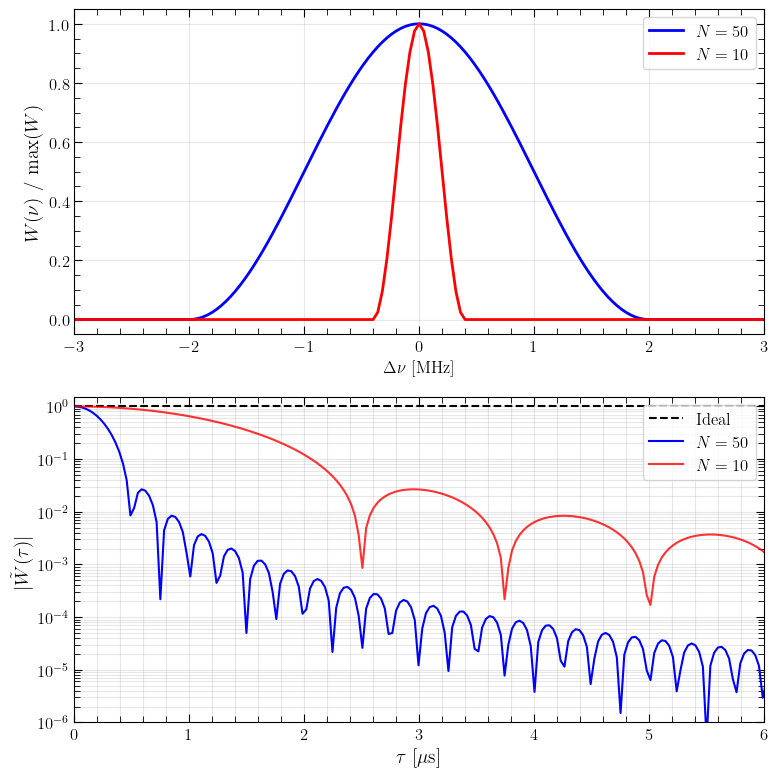

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz

# Frequency Axis (Centered for plotting)
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Window Half-Widths (N)
N_wide = 50   # Wide in Frequency (Stiff)
N_narr = 10   # Narrow in Frequency (Flexible)

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "fig_window_and_transfer_clean.pdf")

# === 2. Calculation ===
def get_window_and_transfer(N_half):
    # 1. Create Window in Frequency
    win = np.zeros(N_chan)
    hann = np.hanning(2 * N_half + 1)
    center = N_chan // 2
    start = center - N_half
    end = start + len(hann)
    
    # Handle boundary safety
    if end > N_chan: end = N_chan
    win[start:end] = hann[:end-start]
    
    # Normalize (sum=1 is physically correct for convolution conservation)
    win_norm = win / win.sum()
    
    # 2. Compute Transfer Function (Delay)
    # The FFT of a real, symmetric window is real and symmetric.
    # We take abs() just to be safe and for log-plotting.
    W_tau = np.abs(fftshift(fft(win_norm)))
    
    return win, W_tau[mask]

# Generate Data
win_wide, W_wide = get_window_and_transfer(N_wide)
win_narr, W_narr = get_window_and_transfer(N_narr)

# === 3. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
plt.subplots_adjust(hspace=0.3)

# --- PANEL A: FREQUENCY DOMAIN (The Window Itself) ---
ax0 = axes[0]

# Normalize peak to 1 for visual comparison of width
ax0.plot(freqs_centered, win_wide / win_wide.max(), 'b-', lw=2, 
         label=r'$N=' + str(N_wide) + '$')
ax0.plot(freqs_centered, win_narr / win_narr.max(), 'r-', lw=2, 
         label=r'$N=' + str(N_narr) + '$')

ax0.set_ylabel(r'$W(\nu) \ / \ \mathrm{max}(W)$', fontsize=14)
ax0.set_xlabel(r'$\Delta\nu\ [\mathrm{MHz}]$', fontsize=12)
ax0.set_xlim(-3, 3) 
ax0.legend(loc='upper right', frameon=True, fontsize=12)
ax0.grid(True, alpha=0.3)
ax0.tick_params(axis='both', which='major', labelsize=12)

# --- PANEL B: DELAY DOMAIN (The Transfer Function) ---
ax1 = axes[1]
ax1.axhline(1.0, color='k', linestyle='--', lw=1.5, label=r'$\mathrm{Ideal}$')

ax1.semilogy(tau_plot, W_wide, 'b-', lw=1.5, 
             label=r'$N=' + str(N_wide) + '$')

ax1.semilogy(tau_plot, W_narr, 'r-', lw=1.5, alpha=0.8, 
             label=r'$N=' + str(N_narr) + '$')

ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
ax1.set_xlabel(r'$\tau\ [\mu\mathrm{s}]$', fontsize=14)

# ZOOM OUT to see tails
ax1.set_xlim(0, 6.0) 
ax1.set_ylim(1e-6, 1.5) # Tightened slightly from 3.0 to 1.5

ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig(save_fname, bbox_inches='tight')
print(f"Plot saved to {save_fname}")
plt.show()

Target FWHM (Hann N=50): 49 bins
Optimizing window widths...
  Hann: Best N = 49 (Diff: 0.00)
  Blackman-Harris: Best N = 71 (Diff: 0.00)
  Nuttall: Best N = 70 (Diff: 0.00)
  Kaiser ($\beta=14$): Best N = 77 (Diff: 0.00)
  DPSS ($NW=3$): Best N = 62 (Diff: 0.00)


/tmp/ipykernel_4163693/3361941500.py:107: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.3)
/tmp/ipykernel_4163693/3361941500.py:146: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/fig_window_matched_fwhm.pdf


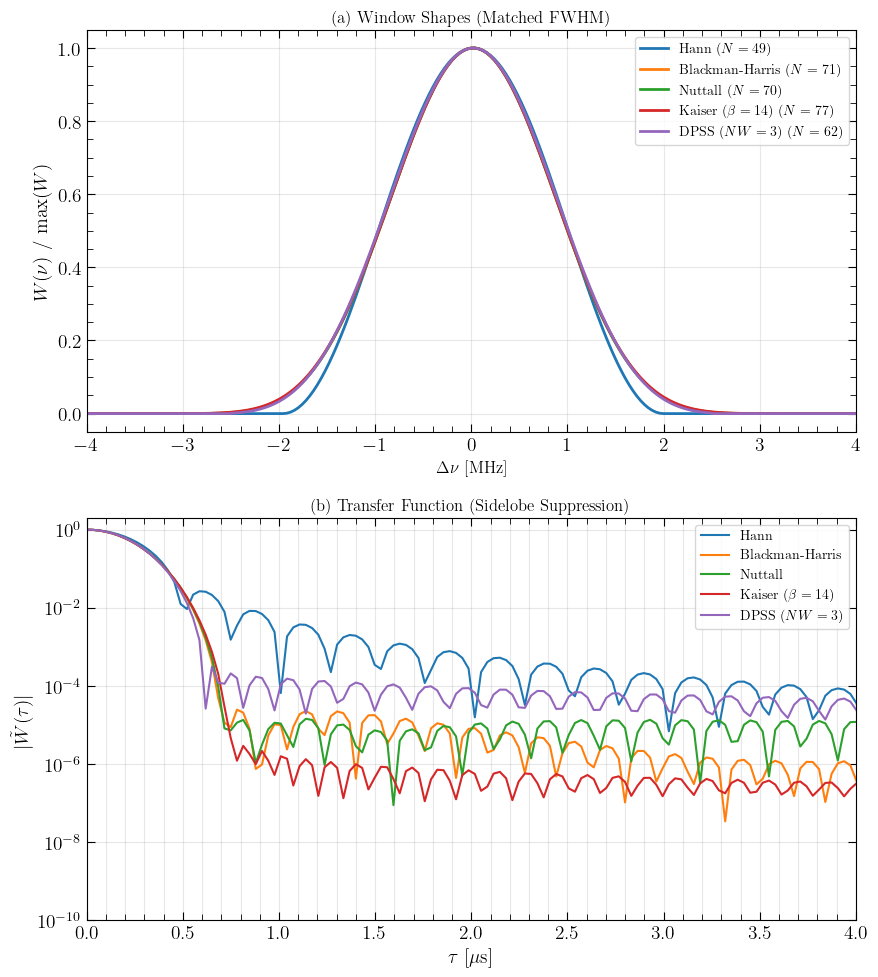

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import get_window
from scipy.interpolate import interp1d
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Reference: Hann Window with N=50
N_ref_half = 50 

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "fig_window_matched_fwhm.pdf")

# === 2. Helper Functions ===

def get_padded_window(w_name, N_half, N_total):
    """Generates a window of length 2*N_half+1, padded to N_total."""
    N_len = 2 * N_half + 1
    
    # get_window handles strings ('hann') or tuples (('kaiser', 14), ('dpss', 3))
    win_kernel = get_window(w_name, N_len)
        
    win_padded = np.zeros(N_total)
    center = N_total // 2
    start = center - N_half
    end = start + len(win_kernel)
    if end > N_total: end = N_total
    win_padded[start:end] = win_kernel[:end-start]
    
    # Normalize (Sum = 1)
    return win_padded / win_padded.sum()

def measure_fwhm(win_padded):
    """Measures FWHM of the window in frequency bins."""
    peak_idx = np.argmax(win_padded)
    peak_val = win_padded[peak_idx]
    half_val = peak_val / 2.0
    
    # Find indices where window > half_val
    indices = np.where(win_padded >= half_val)[0]
    return indices[-1] - indices[0] 

# === 3. Match FWHM ===

# 1. Calculate Target FWHM (Hann, N=50)
win_ref = get_padded_window('hann', N_ref_half, N_chan)
target_fwhm_bins = measure_fwhm(win_ref)

print(f"Target FWHM (Hann N={N_ref_half}): {target_fwhm_bins} bins")

# 2. Find matching N for other windows
# Format: (Label, Scipy_Args)
windows_to_test = [
    ('Hann', 'hann'),
    ('Blackman-Harris', 'blackmanharris'),
    ('Nuttall', 'nuttall'),
    ('Kaiser ($\\beta=14$)', ('kaiser', 14)),
    ('DPSS ($NW=3$)', ('dpss', 3)) 
]

results = {}

print("Optimizing window widths...")
for label, w_name in windows_to_test:
    # Brute force search for N that matches FWHM
    best_N = N_ref_half
    best_diff = 1e9
    
    # Search range: N=10 to N=150
    for N_test in range(10, 150):
        w_test = get_padded_window(w_name, N_test, N_chan)
        fwhm_test = measure_fwhm(w_test)
        diff = abs(fwhm_test - target_fwhm_bins)
        
        if diff < best_diff:
            best_diff = diff
            best_N = N_test
    
    print(f"  {label}: Best N = {best_N} (Diff: {best_diff:.2f})")
    
    # Generate final data
    win_final = get_padded_window(w_name, best_N, N_chan)
    W_tau = np.abs(fftshift(fft(win_final)))
    
    results[label] = {
        'N': best_N,
        'win': win_final,
        'W_tau': W_tau[mask]
    }

# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

fig, axes = plt.subplots(2, 1, figsize=(9, 10))
plt.subplots_adjust(hspace=0.3)

# --- PANEL A: FREQUENCY DOMAIN (Window Shape) ---
ax0 = axes[0]

for label, _ in windows_to_test:
    data = results[label]
    win = data['win']
    N_val = data['N']
    ax0.plot(freqs_centered, win / win.max(), lw=2, 
             label=f"{label} ($N={N_val}$)")

ax0.set_ylabel(r'$W(\nu) \ / \ \mathrm{max}(W)$', fontsize=14)
ax0.set_xlabel(r'$\Delta\nu\ [\mathrm{MHz}]$', fontsize=12)
ax0.set_xlim(-4, 4)
ax0.legend(loc='upper right', frameon=True, fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.set_title(r'$\mathrm{(a)\ Window\ Shapes\ (Matched\ FWHM)}$', fontsize=12)

# --- PANEL B: DELAY DOMAIN (Sidelobes) ---
ax1 = axes[1]
# ax1.axhline(1.0, color='k', linestyle='--', lw=1.5, label=r'$\mathrm{Ideal}$')

for label, _ in windows_to_test:
    data = results[label]
    W_tau = data['W_tau']
    ax1.semilogy(tau_plot, W_tau, lw=1.5, label=label)

ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
ax1.set_xlabel(r'$\tau\ [\mu\mathrm{s}]$', fontsize=14)
ax1.set_title(r'$\mathrm{(b)\ Transfer\ Function\ (Sidelobe\ Suppression)}$', fontsize=12)

# Focus on tails
ax1.set_xlim(0, 4.0)
ax1.set_ylim(1e-10, 2.0)

ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(save_fname, bbox_inches='tight')
print(f"Plot saved to {save_fname}")
plt.show()